In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# We'll now shift to frequency-dependent opacities. These were computed with optool

d2g = 1e-3 # dust-to-gas ratio

wl, kabs, ksca, g_asy = fld.tools.parse_optool_file('opacities/dustkappa_0.1um.inp')
T_opac, kR, kP = fld.tools.compute_mean_opacities(wl, kabs, ksca=ksca, g=g_asy, nT=1000, Tmax=1e5*u.K, Tmin=0.1*u.K)

# the Dust object will automatically assign a function that computes Rosseland and Planck means from this 
# opacity information and interpolates over it, so no need to assign mean opacities

In [3]:
# === grid and star ===
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, T=5772*u.K, wl=wl)
ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=128, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.35, np.pi/2, Nx=256)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

# === initialization of objects ===
Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', debug=False, name='basic')
Dust = fld.fluids.Dust(grid=grid, star=star, irradiation='freqdep', debug=False, name='basic',
                       kabs_wl=kabs, ksca_wl=ksca, g_wl=g_asy,
                       grain_rho=2.08*u.g/u.cm**3, grain_size=0.1*u.um)

# === density and temperature ===
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
# clip the density in the inner regions to mimic the inner rim of the disk
# rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.01))

Gas.set_density(np.ones(grid.shape) * rho)
Dust.set_density(np.ones(grid.shape) * rho * d2g)
Gas.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # starting guess from notebook 1
Dust.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # same starting guess

# === opacities and optical depth ===
# gas opacity is still gray
Gas.enroll_kappaR(lambda f: 1e-3 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1e0 * u.cm**2/u.g)
Gas.enroll_kappaPstar(lambda f: 1e0 * u.cm**2/u.g)

# we pass col0 for the dust since irradiation is frequency-dependent
Gas.enroll_tau0(fld.tools.get_tau0_Flock_2019)
Dust.enroll_col0(fld.tools.get_col0_Flock_2019)

# since we need to account for dust settling, we need a turbulence parameter
Dust.enroll_alpha(lambda f: 1e-1)

# === setup ===
Gas.setup()
Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=True, debug=False, name='disk')

# === boundary conditions ===
# for this problem we simplify a bit by only simulating half the disk -> the x2 domain extends to π/2 and is reflective there
bounds, vals = [fld.grid.BOUNDARY_FIXEDVALUE] * 6, [fld.tools.T_to_Er(10*u.K)] * 6
vals[0] = fld.tools.T_to_Er(400*u.K)
vals[1] = fld.tools.T_to_Er(50*u.K)
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # the value doesn't matter
Disk.declare_boundaries(bounds, vals)

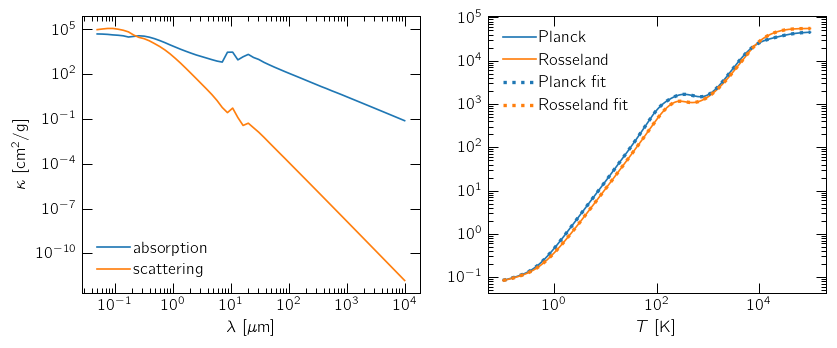

In [4]:
# check that the opacities make sense
fig, ax = plt.subplots(ncols=2, dpi=120, figsize=(8,3))

ax[0].plot(wl.to('um'), kabs.to('cm2/g'), label='absorption')
ax[0].plot(wl.to('um'), ksca.to('cm2/g'), label='scattering')

ax[1].plot(T_opac, kP, c='C0', label='Planck')
ax[1].plot(T_opac, kR, c='C1', label='Rosseland')

# since kappa expects the fluid as an argument (but only uses fluid.tmp),
# make a dummy class that just contains tmp
class Foo: pass
foo = Foo(); foo.tmp = T_opac
ax[1].plot(T_opac, Dust.get_kappaP(foo), c='C0', ls=':', lw=2, label='Planck fit')
ax[1].plot(T_opac, Dust.get_kappaR(foo), c='C1', ls=':', lw=2, label='Rosseland fit')
for axis in ax: axis.legend()
for axis in ax: axis.loglog()
ax[0].set_xlabel(r'$\lambda$ [$\mu$m]')
ax[1].set_xlabel(r'$T$ [K]')
ax[0].set_ylabel(r'$\kappa$ [cm${}^2$/g]')
plt.show()

In [5]:
# run the model
for _ in range(10): Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.
RadiativeEnvironment 'disk': Converged in 3 iterations.


In [6]:
r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]
mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

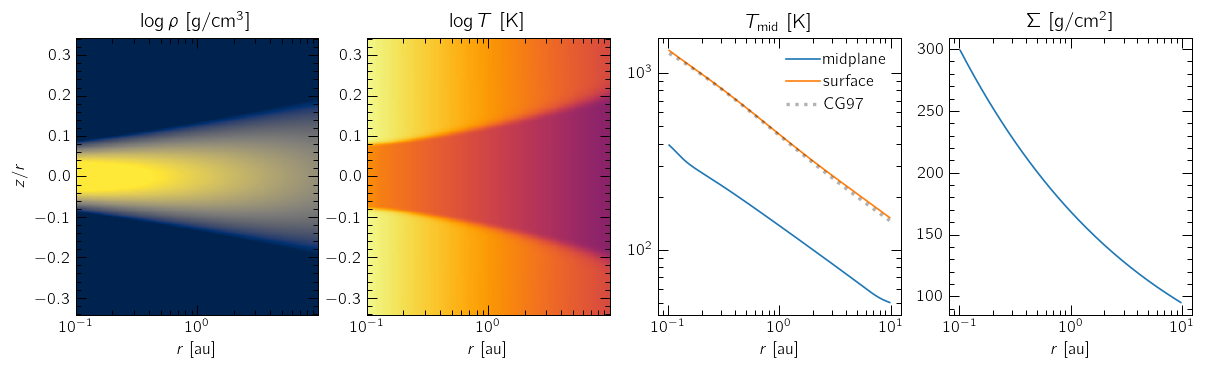

In [7]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = ((d2g*Dust.kappaPstar + Gas.kappaPstar)/(fmt(d2g*Dust.kappaP + Gas.kappaP)))[0] ** 0.25
# opac_factor = (Gas.kappaStar/Gas.kappaP) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [8]:
# now compute the density profile at this steady state
Disk.enforce_hydrostatic_equilibrium()

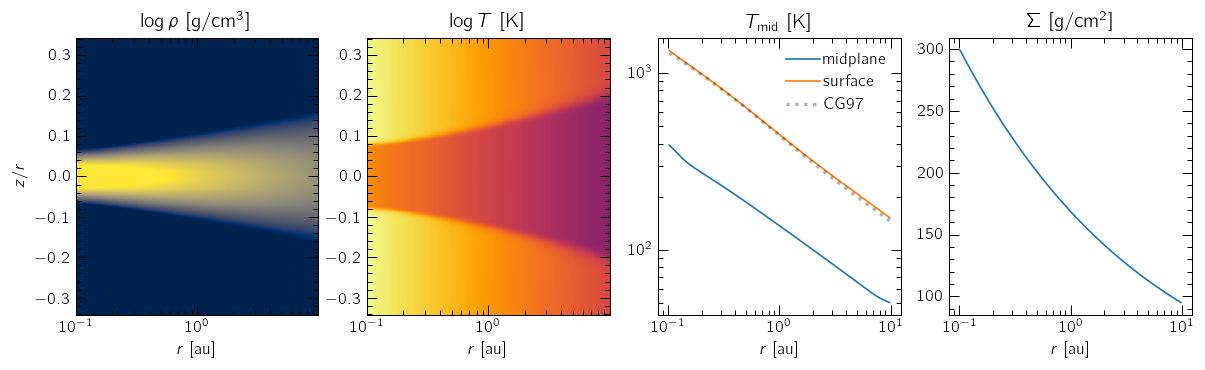

In [9]:
# and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

opac_factor = ((d2g*Dust.kappaPstar + Gas.kappaPstar)/(fmt(d2g*Dust.kappaP + Gas.kappaP)))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [10]:
# run the model again, alternating between temperature and density updates
Disk.verbose = False
for i in range(5):
    for _ in range(30): Disk.advance(dt=1e3 * u.yr)
    Disk.enforce_hydrostatic_equilibrium()
    print(f'finished sypercycle {i}')

finished sypercycle 0
finished sypercycle 1
finished sypercycle 2
finished sypercycle 3
finished sypercycle 4


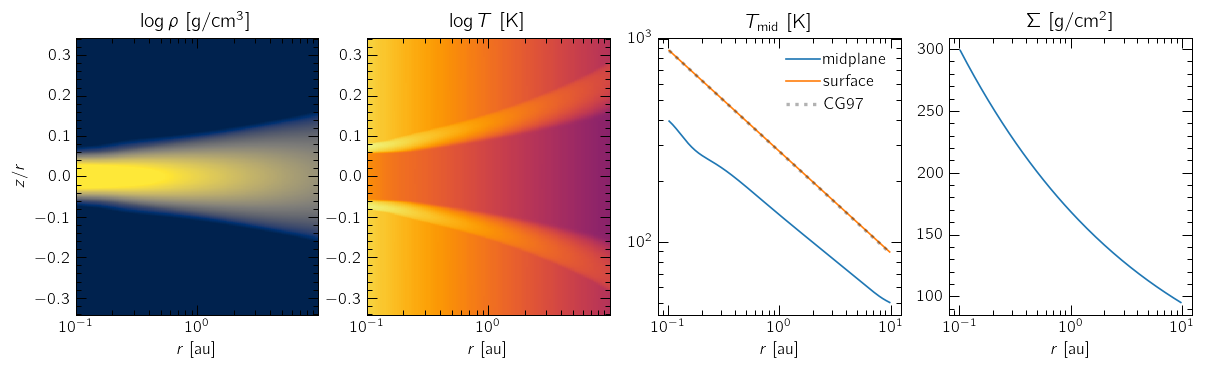

In [11]:
# and check the output again
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# there's only gas at the optically thin layers
opac_factor = (Gas.kappaPstar/Gas.kappaP) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [12]:
# Notice the smoother optical surface with frequency-dependent irradiation.
# Let's also plot the vertical structure to highlight dust settling

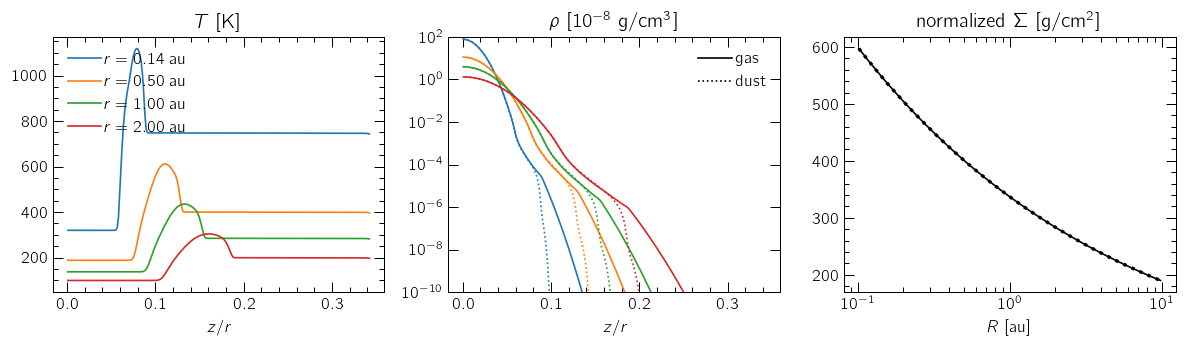

In [13]:
fig, ax = plt.subplots(ncols=3, figsize=(10,3), dpi=120)

g = grid
uden = 1e-10 * u.g / u.cm**3

for idx, r_target in enumerate([0.14, 0.5, 1, 2]):
    c = f'C{idx}'
    ridx = np.argmin(np.abs(r-r_target))
    ax[0].plot(np.cos(theta), fmt(Gas.tmp)[:, ridx].to_value('K'), c=c, label=r'$r=%.2f$ au'%r_target)
    ax[1].plot(np.cos(theta), fmt(Gas.rho)[:, ridx].to_value(uden), c=c)
    ax[1].plot(np.cos(theta), 1/d2g * fmt(Dust.rho)[:, ridx].to_value(uden), c=c, ls=':')

ax[1].plot(np.nan, np.nan, ls='-', c='k', label='gas')
ax[1].plot(np.nan, np.nan, ls=':', c='k', label='dust')

ax[2].plot(r, fld.tools.get_surface_density(g, Gas.rho[g.active])[0].to_value('g/cm2'), c='k', ls='-')
ax[2].plot(r, fld.tools.get_surface_density(g, 1/d2g * Dust.rho[g.active])[0].to_value('g/cm2'), c='k', ls=':', lw=2)

ax[0].legend()
ax[1].legend()

ax[1].set_yscale('log')
ax[1].set_ylim(1e-10, 100)
ax[2].set_xscale('log')

ax[0].set_xlabel(r'$z/r$')
ax[1].set_xlabel(r'$z/r$')
ax[2].set_xlabel(r'$R$ [au]')

ax[0].set_title(r'$T$ [K]')
ax[1].set_title(r'$\rho$ [$10^{-8}$ g/cm${}^3$]')
ax[2].set_title(r'normalized $\Sigma$ [g/cm${}^2$]')

fig.tight_layout()

plt.show()

In [14]:
# try writing the output

Disk.write_snapshot(dirc='models', name='4-snapshot')

In [15]:
# now read it and verify it plots the same quantities

Disk_new = fld.FLD.create_from_snapshot(dirc='models', name='4-snapshot')
Gas_new = Disk_new.fluids[0]
Dust_new = Disk_new.fluids[1]

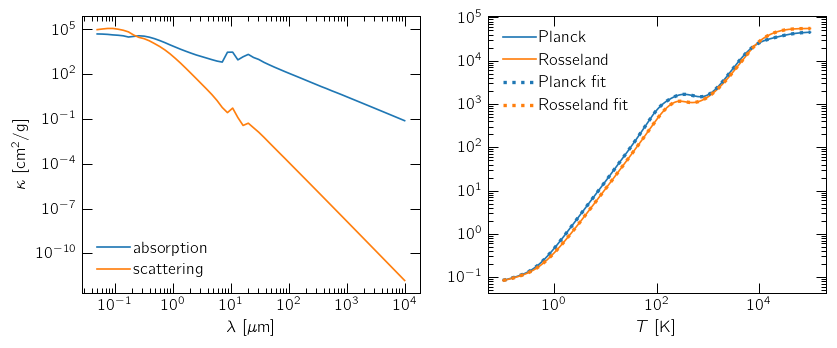

In [16]:
# check that the opacities make sense
fig, ax = plt.subplots(ncols=2, dpi=120, figsize=(8,3))

ax[0].plot(wl.to('um'), kabs.to('cm2/g'), label='absorption')
ax[0].plot(wl.to('um'), ksca.to('cm2/g'), label='scattering')

ax[1].plot(T_opac, kP, c='C0', label='Planck')
ax[1].plot(T_opac, kR, c='C1', label='Rosseland')

# since kappa expects the fluid as an argument (but only uses fluid.tmp),
# make a dummy class that just contains tmp
class Foo: pass
foo = Foo(); foo.tmp = T_opac
ax[1].plot(T_opac, Dust_new.get_kappaP(foo), c='C0', ls=':', lw=2, label='Planck fit')
ax[1].plot(T_opac, Dust_new.get_kappaR(foo), c='C1', ls=':', lw=2, label='Rosseland fit')
for axis in ax: axis.legend()
for axis in ax: axis.loglog()
ax[0].set_xlabel(r'$\lambda$ [$\mu$m]')
ax[1].set_xlabel(r'$T$ [K]')
ax[0].set_ylabel(r'$\kappa$ [cm${}^2$/g]')
plt.show()

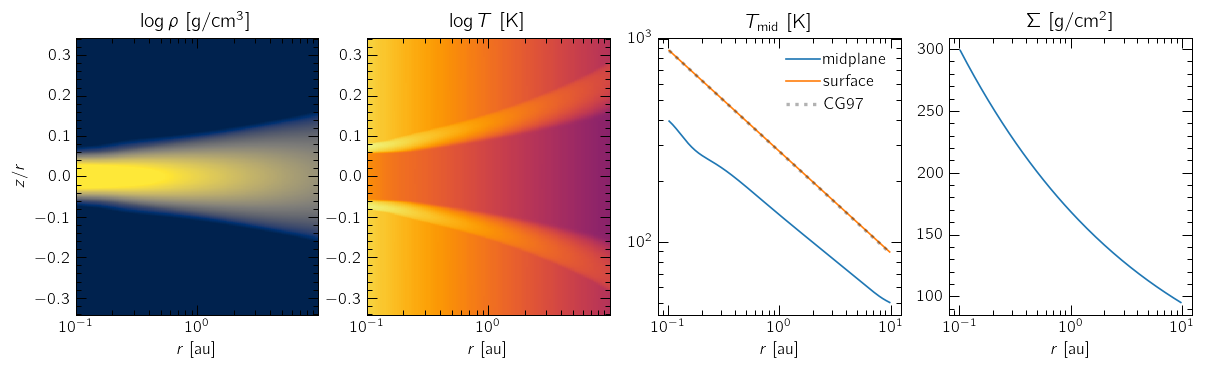

In [17]:
# and check the output again
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk_new.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk_new.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk_new.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk_new.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk_new.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk_new.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk_new.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# there's only gas at the optically thin layers
opac_factor = (Gas_new.kappaPstar/Gas_new.kappaP) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

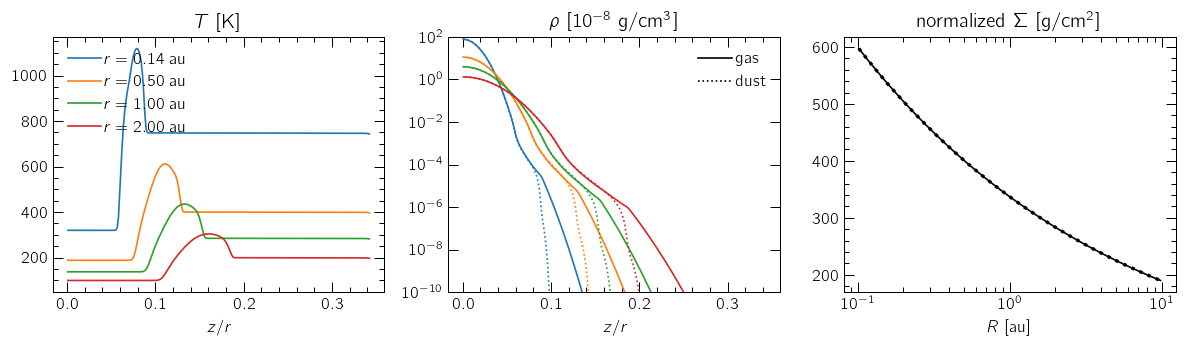

In [18]:
fig, ax = plt.subplots(ncols=3, figsize=(10,3), dpi=120)

g = grid
uden = 1e-10 * u.g / u.cm**3

for idx, r_target in enumerate([0.14, 0.5, 1, 2]):
    c = f'C{idx}'
    ridx = np.argmin(np.abs(r-r_target))
    ax[0].plot(np.cos(theta), fmt(Gas_new.tmp)[:, ridx].to_value('K'), c=c, label=r'$r=%.2f$ au'%r_target)
    ax[1].plot(np.cos(theta), fmt(Gas_new.rho)[:, ridx].to_value(uden), c=c)
    ax[1].plot(np.cos(theta), 1/d2g * fmt(Dust_new.rho)[:, ridx].to_value(uden), c=c, ls=':')

ax[1].plot(np.nan, np.nan, ls='-', c='k', label='gas')
ax[1].plot(np.nan, np.nan, ls=':', c='k', label='dust')

ax[2].plot(r, fld.tools.get_surface_density(g, Gas_new.rho[g.active])[0].to_value('g/cm2'), c='k', ls='-')
ax[2].plot(r, fld.tools.get_surface_density(g, 1/d2g * Dust_new.rho[g.active])[0].to_value('g/cm2'), c='k', ls=':', lw=2)

ax[0].legend()
ax[1].legend()

ax[1].set_yscale('log')
ax[1].set_ylim(1e-10, 100)
ax[2].set_xscale('log')

ax[0].set_xlabel(r'$z/r$')
ax[1].set_xlabel(r'$z/r$')
ax[2].set_xlabel(r'$R$ [au]')

ax[0].set_title(r'$T$ [K]')
ax[1].set_title(r'$\rho$ [$10^{-8}$ g/cm${}^3$]')
ax[2].set_title(r'normalized $\Sigma$ [g/cm${}^2$]')

fig.tight_layout()

plt.show()

In [19]:
np.abs(Gas_new.rho - Gas.rho).max().cgs

<Quantity 0. g / cm3>